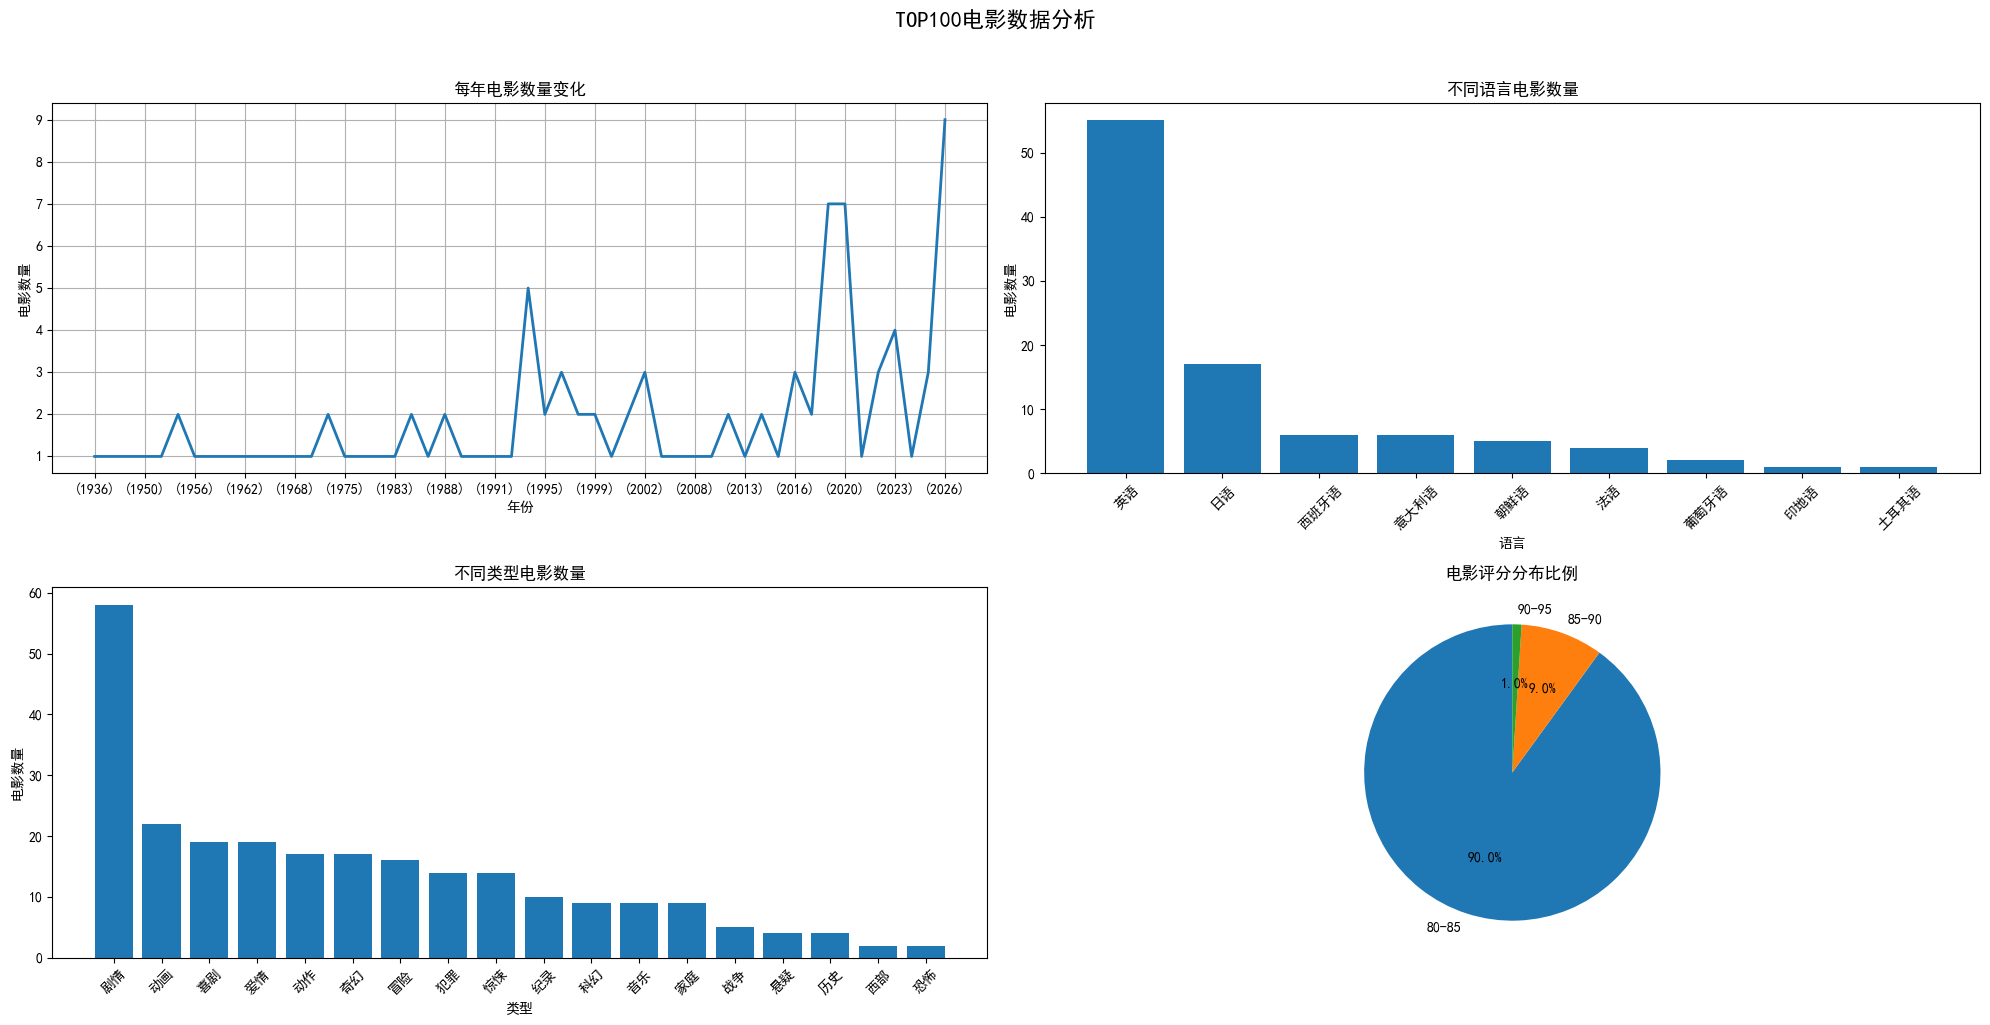

In [7]:
# 导入必要的库
import pandas as pd
import matplotlib.pyplot as plt

# 设置中文显示和负号正常显示
plt.rcParams['font.sans-serif']=['SimHei'] 
plt.rcParams['axes.unicode_minus'] = False

# 读取数据
df = pd.read_csv('movie_list.csv', usecols=['电影名','年份','类型','评分','语言'])

# 创建2x2的子图布局
fig, axes = plt.subplots(2, 2, figsize=(20, 10))
fig.suptitle('TOP100电影数据分析', fontsize=16, y=1.02)

# 1. 每一年电影数量的变化（折线图）
# 按年份分组并计数
year_counts = df['年份'].value_counts().sort_index()
axes[0, 0].plot(year_counts.index, year_counts.values, linewidth=2, markersize=8)
axes[0, 0].set_title('每年电影数量变化')
axes[0, 0].set_xlabel('年份')
axes[0, 0].set_ylabel('电影数量')
axes[0, 0].grid(True)
axes[0, 0].xaxis.set_major_locator(plt.MultipleLocator(3))  # 设置x轴刻度间隔为5

# 2. 不同语言电影的数量（柱状图）
# 按语言分组并计数
lang_counts = df[df['语言'] != '-'] ['语言'].value_counts()
axes[0, 1].bar(lang_counts.index, lang_counts.values)
axes[0, 1].set_title('不同语言电影数量')
axes[0, 1].set_xlabel('语言')
axes[0, 1].set_ylabel('电影数量')
axes[0, 1].tick_params(axis='x', rotation=45)  # 旋转x轴标签

# 3. 不同类型电影的数量（柱状图）
# 按类型分组并计数
type_list = []
for types in df['类型'].str.split(','):  # 假设类型是用'/'分隔的
    type_list.extend(types)
type_counts = pd.Series(type_list).value_counts()
axes[1, 0].bar(type_counts.index, type_counts.values)
axes[1, 0].set_title('不同类型电影数量')
axes[1, 0].set_xlabel('类型')
axes[1, 0].set_ylabel('电影数量')
axes[1, 0].tick_params(axis='x', rotation=45)  # 旋转x轴标签


# 4. 各个电影的评分的比例（饼图）
# 按评分区间分组并计数
bins = [ 80, 85, 90, 95]  # 定义评分区间
labels = ['80-85', '85-90', '90-95']
# 在进行分箱前先删除NaN值
score_ranges = pd.cut(df['评分'].dropna(), bins=bins, labels=labels)
score_counts = score_ranges.value_counts()
axes[1, 1].pie(score_counts.values, labels=score_counts.index, autopct='%1.1f%%', startangle=90)
axes[1, 1].set_title('电影评分分布比例')
# 保存图像
plt.savefig('电影数据分析.png', dpi=100)

# 调整子图间距
plt.tight_layout()
plt.show()
